### LSTM

#### 一、核心直接：传送带
LSTM最天才的设计是引入了细胞状态。可以将它想象成一条贯穿整个序列的“传送带”
- 信息在传送带上流过，只有一些微小的线性交互
- 如果没有干扰，信息可以原封不懂地从序列开头传到结尾
- 门则是传送带地管理员，负责决定哪些信息该进入，那些该出去

#### 二、三大管理员：LSTM的门控机制
- 遗忘门:
  - 职责：决定要从旧记忆里扔掉什么
  - 逻辑：比如你在读一段关于“张三”的故事，突然主语变成了“李四”，遗忘门就会把关于“张三”的一些过时特征清理掉
- 输入门：
  - 职责：决定哪些新信息值得存入档案
  - 逻辑：筛选当前输入，挑选重要的部分进行更新
- 输出门：
  - 职责：决定当前要表现什么
  - 逻辑：档案里存在很多东西，此刻根据上下文，只需要输出一部分

#### 三、应用场景
- 长时间序列预测
- 金融量化交易
- 自然语言处理：机器翻译、文本生成、情感分析
- 语言识别与合成
- 工业设备预测性维护
- 异常检测

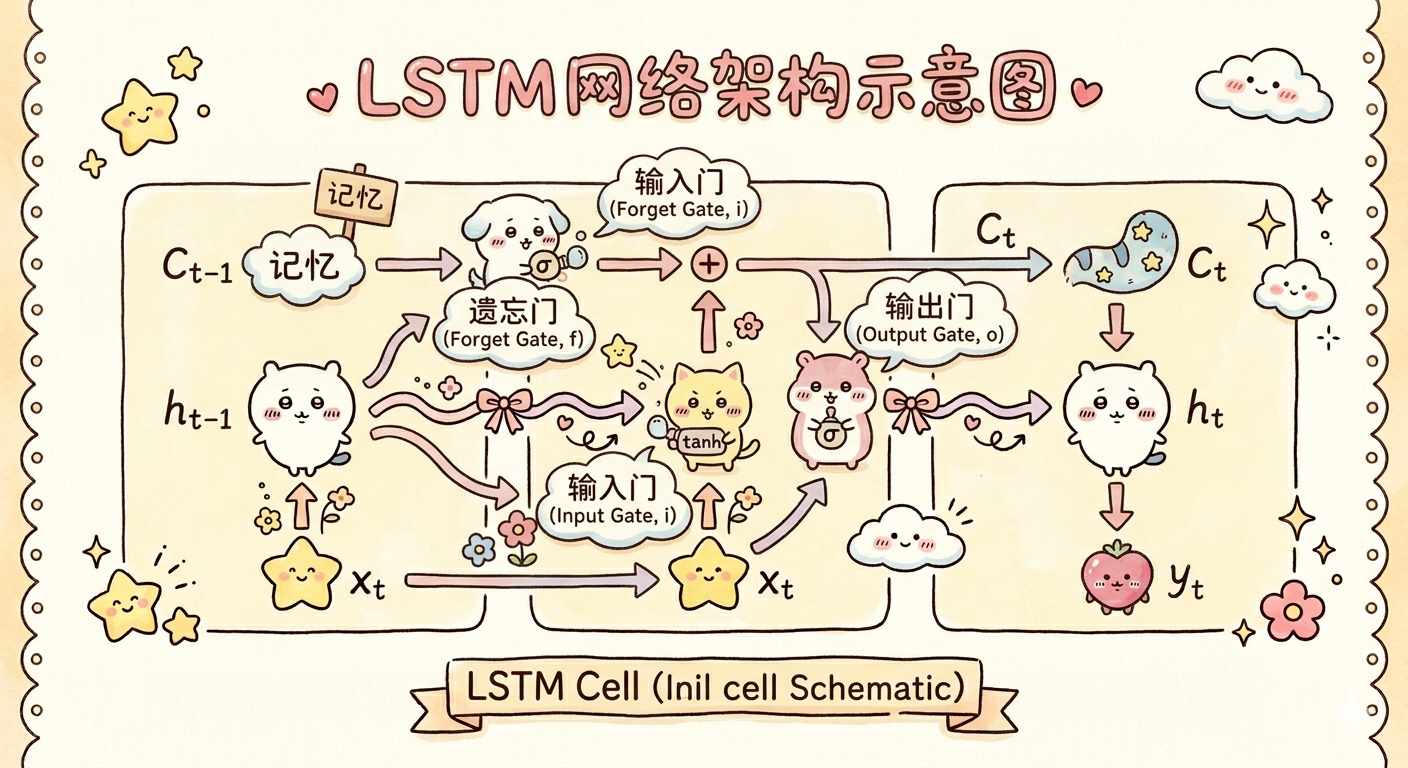

### 案例：股价预测
- 数据：利用Tushare获取的股票数据，包括贵州茅台2010-2025年的日线数据

In [1]:
import tushare as ts
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

In [2]:
token = '112807077fb46e02a0f4f4dbf69c700b897c3bbf6d641138609b20e9'
ts.set_token(token)
pro = ts.pro_api()

df_daily = pro.daily(ts_code='600519.SH',
                     start_date='20100101',
                     end_date='20251231')
df_daily = df_daily.sort_values('trade_date').reset_index(drop=True)

# 添加暴跌标记
df_daily['Crash'] = (df_daily['close'].pct_change() < -0.05).astype(int)

# 计算技术指标
def add_technical_features(df):
    df['MA7'] = df['close'].rolling(7).mean()
    df['MA21'] = df['close'].rolling(21).mean()
    exp12 = df['close'].ewm(span=12, adjust=False).mean()
    exp26 = df['close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp12 - exp26
    df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['Volatility'] = df['close'].rolling(20).std()
    return df

df = add_technical_features(df_daily).dropna().reset_index(drop=True)

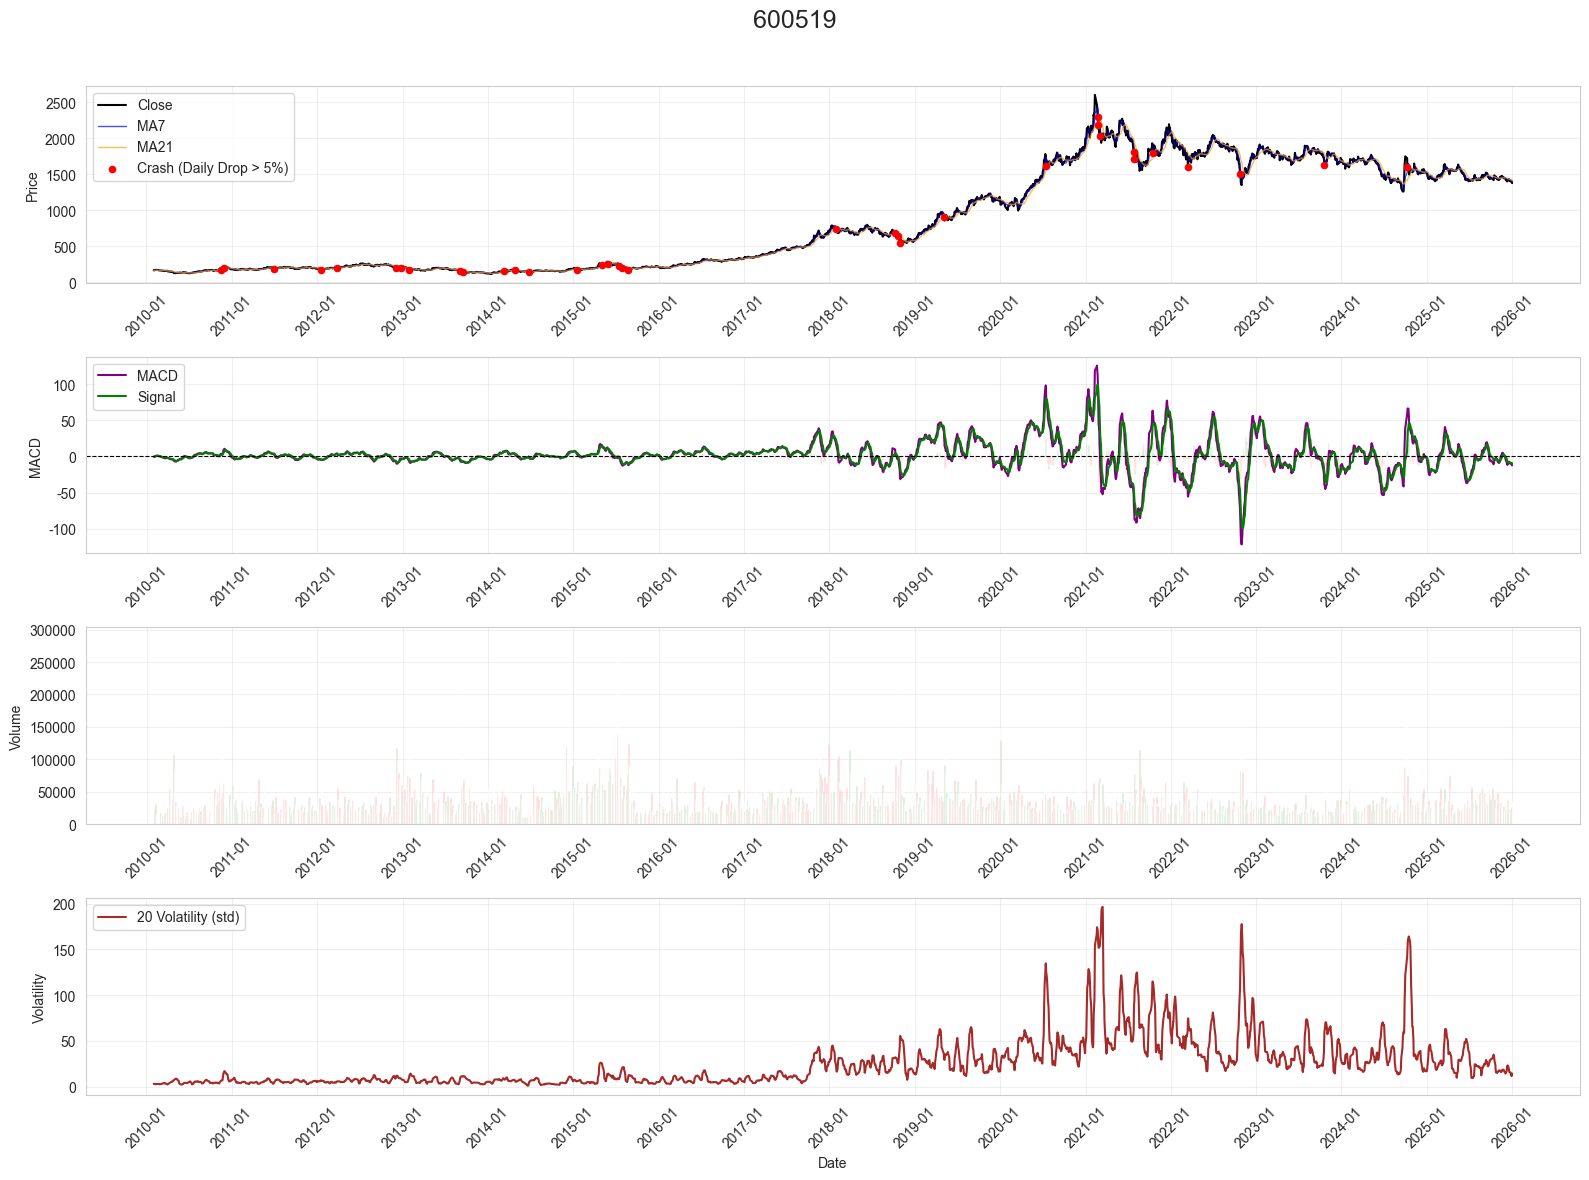

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 设置中文显示和样式
plt.rcParams['font.family'] = 'SimSun'
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
sns.set_style('whitegrid')

df['trade_date'] = pd.to_datetime(df['trade_date'])

# 创建画布和子图
fig = plt.figure(figsize=(16, 12))
fig.suptitle('600519', fontsize=18, y=0.98)

ax1 = plt.subplot(4, 1, 1)
ax1.plot(df['trade_date'], df['close'], label='Close', color='black', linewidth=1.5)
ax1.plot(df['trade_date'], df['MA7'], label='MA7', color='blue', alpha=0.7, linewidth=1)
ax1.plot(df['trade_date'], df['MA21'], label='MA21', color='orange', alpha=0.7, linewidth=1)
# 标记暴跌点
crash_dates = df[df['Crash'] == 1]['trade_date']
crash_prices = df[df['Crash'] == 1]['close']
ax1.scatter(crash_dates, crash_prices, color='red', s=20, label='Crash (Daily Drop > 5%)', zorder=3)
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# MACD 与信号线
ax2 = plt.subplot(4, 1, 2)
ax2.plot(df['trade_date'], df['MACD'], label='MACD', color='purple')
ax2.plot(df['trade_date'], df['Signal'], label='Signal', color='green')
# 绘制柱状线 (MACD - Signal)
ax2.bar(df['trade_date'], df['MACD'] - df['Signal'], 
        color=['red' if val < 0 else 'green' for val in (df['MACD'] - df['Signal'])], 
        alpha=0.3, width=0.8)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_ylabel('MACD')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# 成交量 (柱状图)
ax3 = plt.subplot(4, 1, 3)
# 根据涨跌着色: 涨为红色，跌为绿色 (国内惯例)
colors = ['red' if close >= open_ else 'green' 
          for close, open_ in zip(df['close'], df['open'])]
ax3.bar(df['trade_date'], df['vol'], color=colors, alpha=0.6, width=0.8)
ax3.set_ylabel('Volume')
ax3.grid(True, alpha=0.3)

# 波动率
ax4 = plt.subplot(4, 1, 4)
ax4.plot(df['trade_date'], df['Volatility'], label='20 Volatility (std)', color='brown')
ax4.set_xlabel('Date')
ax4.set_ylabel('Volatility')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3)

# 格式化x轴日期 (避免过于拥挤)
for ax in [ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()

In [4]:
features = ['open', 'high', 'low', 'close', 'vol', 'MA7', 'MA21', 'MACD', 'Signal', 'Volatility']
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(df[features])

# 构造时间窗口（60天预测下一天）
window_size = 60
X, y = [], []
for i in range(window_size, len(scaled_features)):
    X.append(scaled_features[i - window_size:i])   # 过去60天
    y.append(scaled_features[i, 3])                # 第61天的close（归一化后）

X, y = np.array(X), np.array(y)

In [5]:
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:-30]   # 最后30天作为测试集
y_train, y_val = y[:split_idx], y[split_idx:-30]
X_test, y_test = X[-30:], y[-30:]                  # 测试集30个样本

# 转换为Tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

c:\Users\23017\anaconda3\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Epoch 1/200, Train Loss: 0.014619, Val Loss: 0.000856
Epoch 2/200, Train Loss: 0.001169, Val Loss: 0.000297
Epoch 3/200, Train Loss: 0.000775, Val Loss: 0.000364
EarlyStopping counter: 1 out of 10
Epoch 4/200, Train Loss: 0.000718, Val Loss: 0.001046
EarlyStopping counter: 2 out of 10
Epoch 5/200, Train Loss: 0.000789, Val Loss: 0.000207
Epoch 6/200, Train Loss: 0.000600, Val Loss: 0.000585
EarlyStopping counter: 1 out of 10
Epoch 7/200, Train Loss: 0.000570, Val Loss: 0.000572
EarlyStopping counter: 2 out of 10
Epoch 8/200, Train Loss: 0.000533, Val Loss: 0.000227
EarlyStopping counter: 3 out of 10
Epoch 9/200, Train Loss: 0.000519, Val Loss: 0.000198
Epoch 10/200, Train Loss: 0.000504, Val Loss: 0.000468
EarlyStopping counter: 1 out of 10
Epoch 11/200, Train Loss: 0.000449, Val Loss: 0.000326
EarlyStopping counter: 2 out of 10
Epoch 12/200, Train Loss: 0.000493, Val Loss: 0.000907
EarlyStopping counter: 3 out of 10
Epoch 13/200, Train Loss: 0.000524, Val Loss: 0.000457
EarlyStopping 

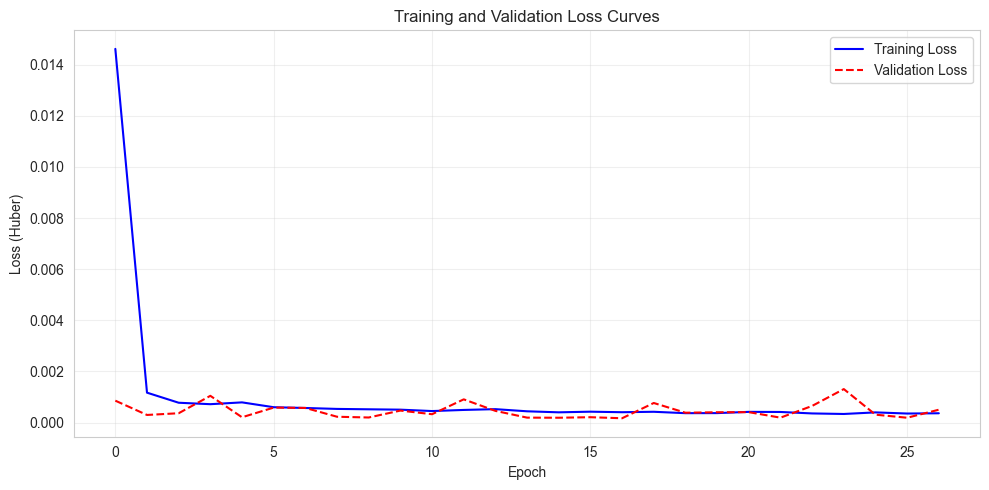

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=128, hidden_size2=64, output_size=1, dropout_rate=0.3):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True, dropout=0.2)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True, dropout=0.2)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size2, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, output_size)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out = out[:, -1, :]          # 取最后一个时间步
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out


class EarlyStopping:
    def __init__(self, patience=10, verbose=True, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        return self.early_stop

    def restore_best_weights(self, model):
        model.load_state_dict(self.best_model_state)


input_dim = X.shape[2]
model = LSTMModel(input_size=input_dim)
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
early_stopping = EarlyStopping(patience=10, verbose=True)

# 在训练前初始化
train_losses = []
val_losses = []

epochs = 200
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)      # 记录

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)          # 记录

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    if early_stopping(val_loss, model):
        print("Early stopping triggered")
        break

early_stopping.restore_best_weights(model)
print("Training finished. Best weights restored.")

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=1.5)
plt.plot(val_losses, label='Validation Loss', color='red', linewidth=1.5, linestyle='--')
plt.title('Training and Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).numpy()          # 归一化预测值
    test_true = y_test_t.numpy()                  # 归一化真实值

# 反归一化
def inverse_close(scaled_features_full, close_scaled, sample_index):
    """scaled_features_full: 原始归一化后的完整特征数组（形状[n_samples, n_features]）
       close_scaled: 要反归一化的close值（标量或数组）
       sample_index: 对应样本在scaled_features_full中的索引（用于获取其他特征）"""
    # 复制最后一天的特征向量
    feat = scaled_features_full[sample_index].copy()
    feat[3] = close_scaled   # close列索引为3
    # 反归一化整行，再取close列
    inv = scaler.inverse_transform(feat.reshape(1, -1))
    return inv[0, 3]

test_last_indices = list(range(len(scaled_features) - 30, len(scaled_features)))  # 共30个，每个是窗口最后一天的位置

pred_prices = []
true_prices = []
for i, idx in enumerate(test_last_indices):
    pred_scaled = test_preds[i, 0]
    true_scaled = test_true[i, 0]
    pred_price = inverse_close(scaled_features, pred_scaled, idx)
    true_price = inverse_close(scaled_features, true_scaled, idx)
    pred_prices.append(pred_price)
    true_prices.append(true_price)

# 打印测试集结果
print(f"平均绝对误差 (MAE): {np.mean(np.abs(np.array(pred_prices) - np.array(true_prices))):.2f}")
print(f"均方根误差 (RMSE): {np.sqrt(np.mean((np.array(pred_prices) - np.array(true_prices))**2)):.2f}")


平均绝对误差 (MAE): 15.03
均方根误差 (RMSE): 17.69


In [10]:
last_60_features = scaled_features[-60:]                     # 最近60天完整特征
last_60_tensor = torch.tensor(last_60_features, dtype=torch.float32).unsqueeze(0)  # shape (1,60,10)
with torch.no_grad():
    next_close_scaled = model(last_60_tensor).item()

next_close_price = inverse_close(scaled_features, next_close_scaled, -1)
print(f"\n根据最近60天数据预测下一个交易日的收盘价: {next_close_price:.2f}")


根据最近60天数据预测下一个交易日的收盘价: 1403.08


MSE  (均方误差): 313.01
MAE  (平均绝对误差): 15.03
RMSE (均方根误差): 17.69
R²   (决定系数): 0.3352


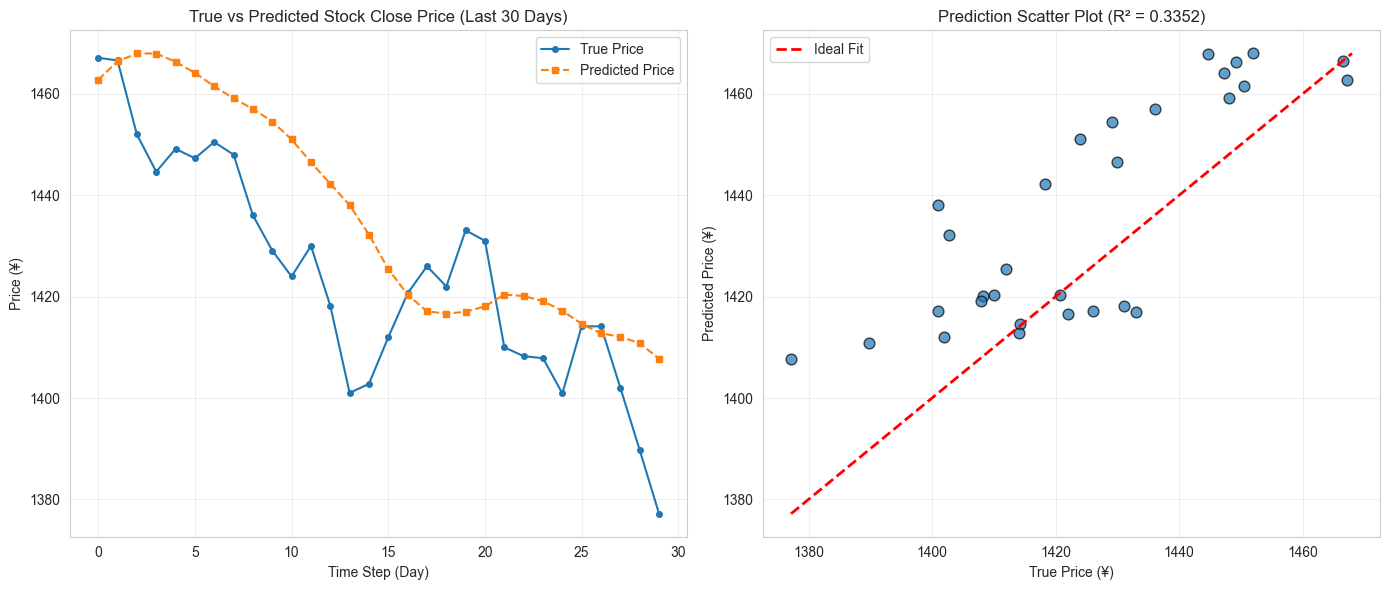

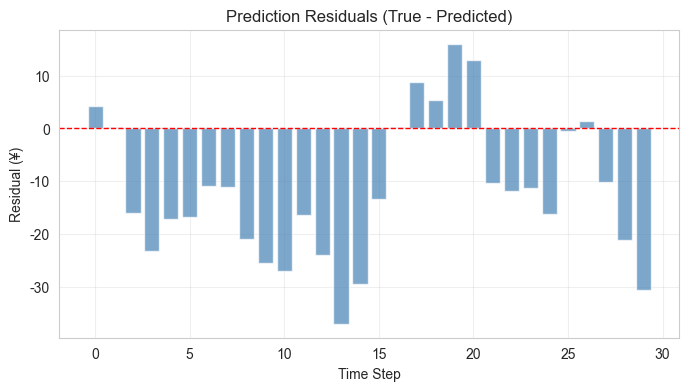

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pred_prices = np.array(pred_prices)
true_prices = np.array(true_prices)

mse = mean_squared_error(true_prices, pred_prices)
mae = mean_absolute_error(true_prices, pred_prices)
rmse = np.sqrt(mse)
r2 = r2_score(true_prices, pred_prices)

print(f"MSE  (均方误差): {mse:.2f}")
print(f"MAE  (平均绝对误差): {mae:.2f}")
print(f"RMSE (均方根误差): {rmse:.2f}")
print(f"R²   (决定系数): {r2:.4f}")


plt.figure(figsize=(14, 6))

# 真实值 vs 预测值（折线图）
plt.subplot(1, 2, 1)
plt.plot(true_prices, label='True Price', marker='o', linestyle='-', linewidth=1.5, markersize=4)
plt.plot(pred_prices, label='Predicted Price', marker='s', linestyle='--', linewidth=1.5, markersize=4)
plt.title('True vs Predicted Stock Close Price (Last 30 Days)')
plt.xlabel('Time Step (Day)')
plt.ylabel('Price (¥)')
plt.legend()
plt.grid(True, alpha=0.3)

# 散点图 + 理想对角线
plt.subplot(1, 2, 2)
plt.scatter(true_prices, pred_prices, alpha=0.7, edgecolors='k', s=60)
# 绘制 y=x 参考线
min_val = min(true_prices.min(), pred_prices.min())
max_val = max(true_prices.max(), pred_prices.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')
plt.title(f'Prediction Scatter Plot (R² = {r2:.4f})')
plt.xlabel('True Price (¥)')
plt.ylabel('Predicted Price (¥)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 残差图（诊断预测误差分布）
plt.figure(figsize=(8, 4))
residuals = true_prices - pred_prices
plt.bar(range(len(residuals)), residuals, color='steelblue', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.title('Prediction Residuals (True - Predicted)')
plt.xlabel('Time Step')
plt.ylabel('Residual (¥)')
plt.grid(True, alpha=0.3)
plt.show()